# Employee Attrition — Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Employee_Attrition_Prediction.csv")

print("Shape:", df.shape)

Shape: (1470, 35)


In [3]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [4]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

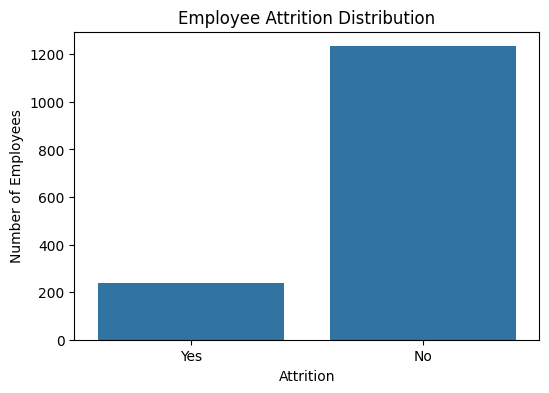

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

# Age

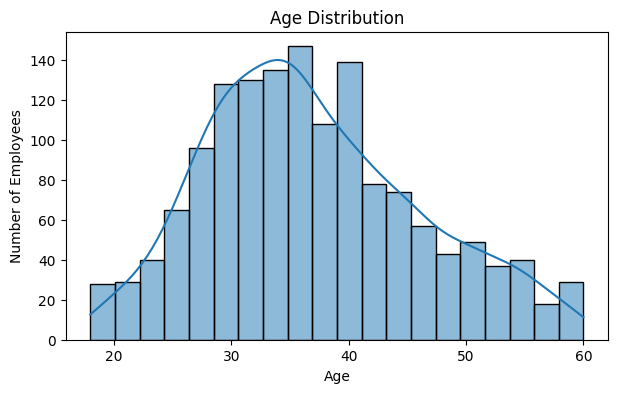

In [6]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

# Monthly Income

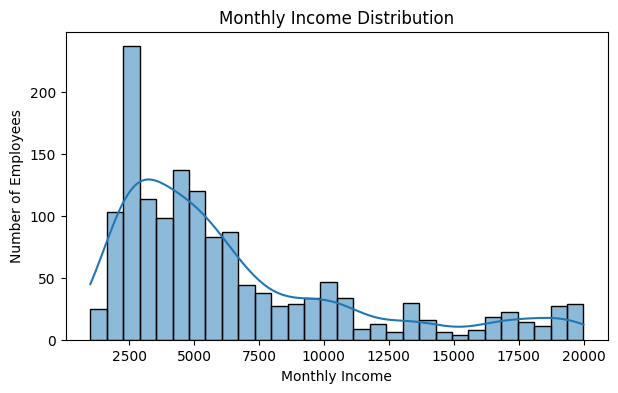

In [7]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

# Total Working Years

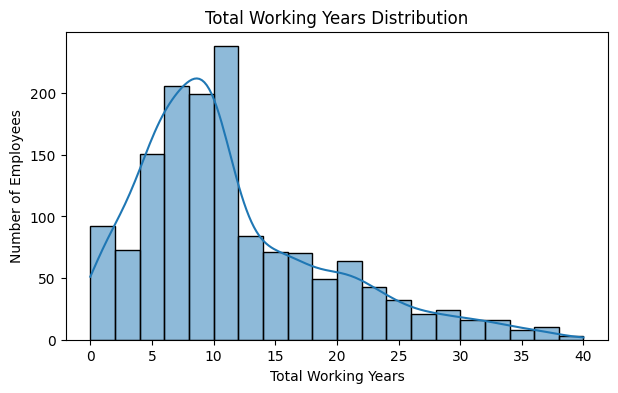

In [8]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="TotalWorkingYears",
    bins=20,
    kde=True
)

plt.title("Total Working Years Distribution")
plt.xlabel("Total Working Years")
plt.ylabel("Number of Employees")

plt.show()

# Years at Company

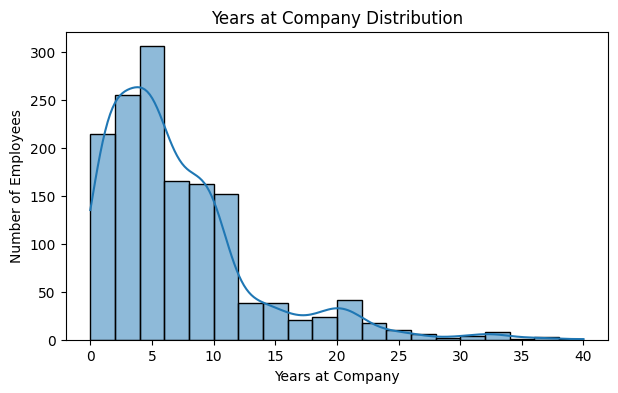

In [9]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    bins=20,
    kde=True
)

plt.title("Years at Company Distribution")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.show()

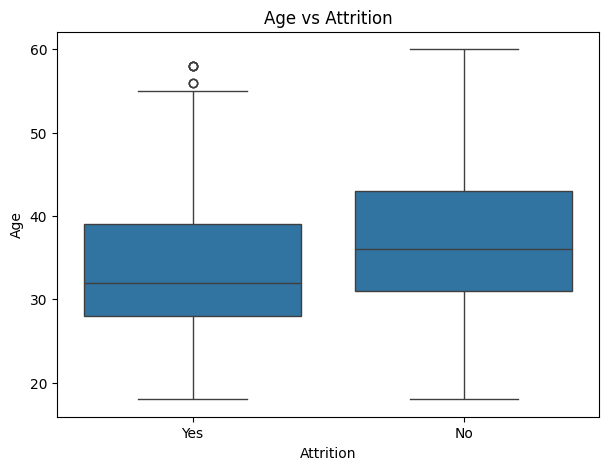

In [10]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

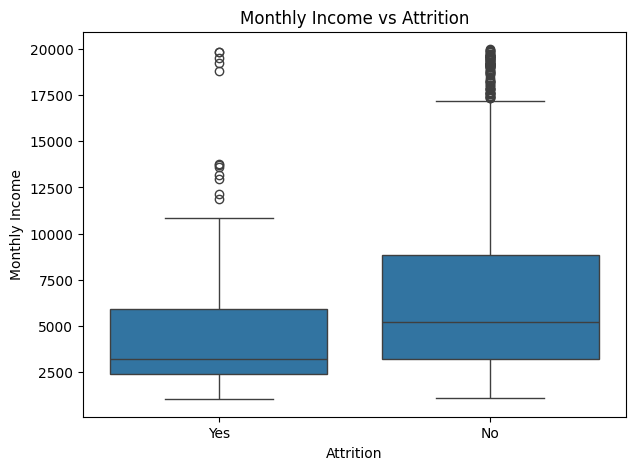

In [11]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

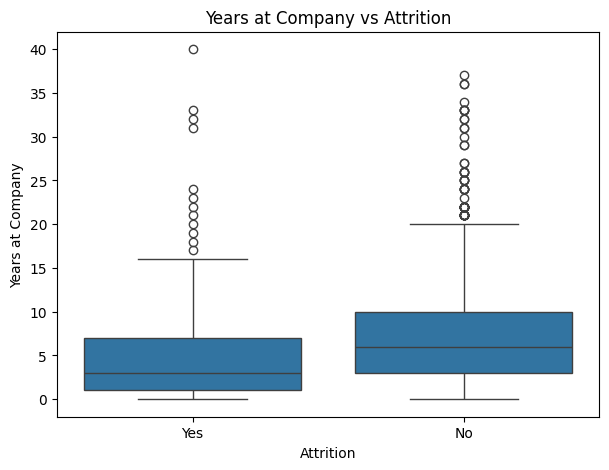

In [12]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

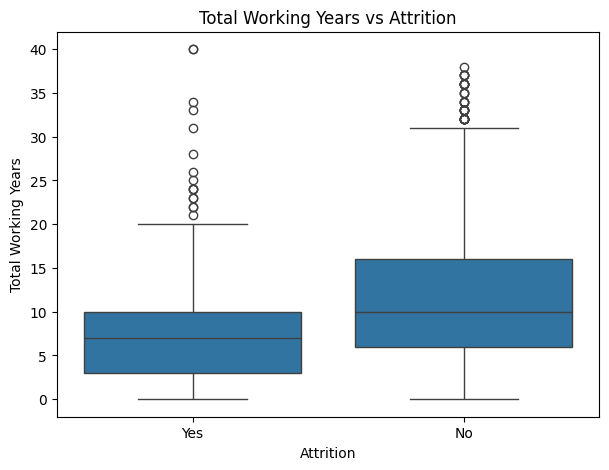

In [13]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="TotalWorkingYears"
)

plt.title("Total Working Years vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Total Working Years")

plt.show()

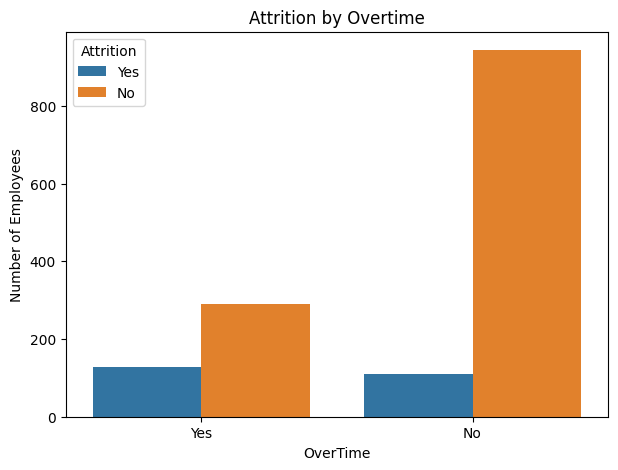

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.show()

In [15]:
overtime_attrition = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


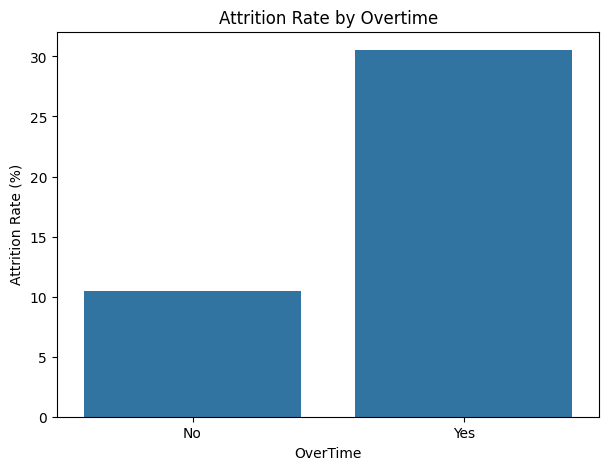

In [16]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition["Yes"]
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [17]:
joblevel_attrition = (
    pd.crosstab(
        df["JobLevel"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

joblevel_attrition

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


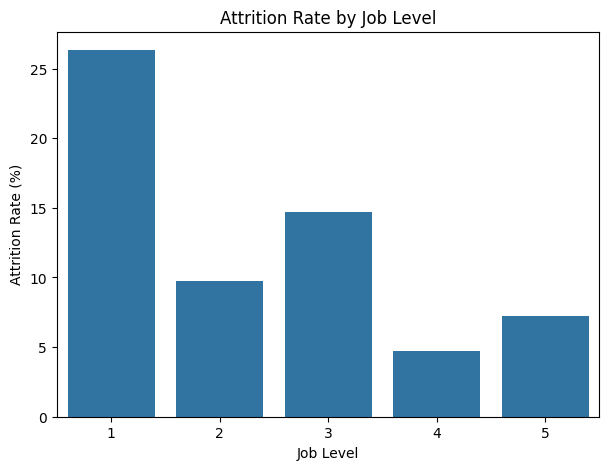

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=joblevel_attrition.index,
    y=joblevel_attrition["Yes"]
)

plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [19]:
satisfaction_attrition = (
    pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

satisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


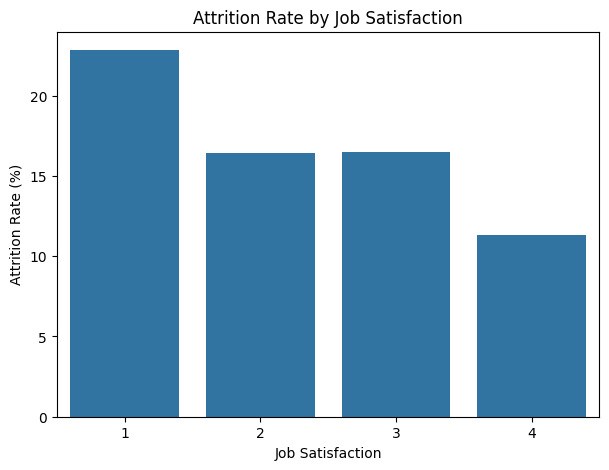

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=satisfaction_attrition.index,
    y=satisfaction_attrition["Yes"]
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.show()

## Initial EDA Findings

### Target
- Attrition is imbalanced, with approximately 16% positive cases.

### Numerical features
- Age shows a moderate difference between employees who stayed and left.
- Employees who left tend to have lower MonthlyIncome.
- Employees who left tend to have fewer TotalWorkingYears.
- Employees who left tend to have fewer YearsAtCompany.
- Several numerical variables are right-skewed, particularly MonthlyIncome and YearsAtCompany.
- Observed outliers have not been removed because extreme values may represent legitimate employees.

### Categorical / ordinal features
- OverTime shows a strong association with attrition.
- Low JobSatisfaction is associated with higher attrition.
- JobLevel 1 has substantially higher attrition than most other job levels.
- JobLevel does not show a perfectly monotonic relationship with attrition.

### Important hypotheses for further investigation
- Age, TotalWorkingYears, and YearsAtCompany may be correlated.
- Several features may contain overlapping information.
- Feature relationships should be evaluated jointly rather than individually.

### Important limitation
These observations describe associations in the dataset and do not establish causation.

## Numerical Feature Relationships

Before modeling, we check correlations between numerical features.

This helps us identify:
- strongly related features
- potentially redundant information
- possible multicollinearity
- relationships that may affect model interpretation

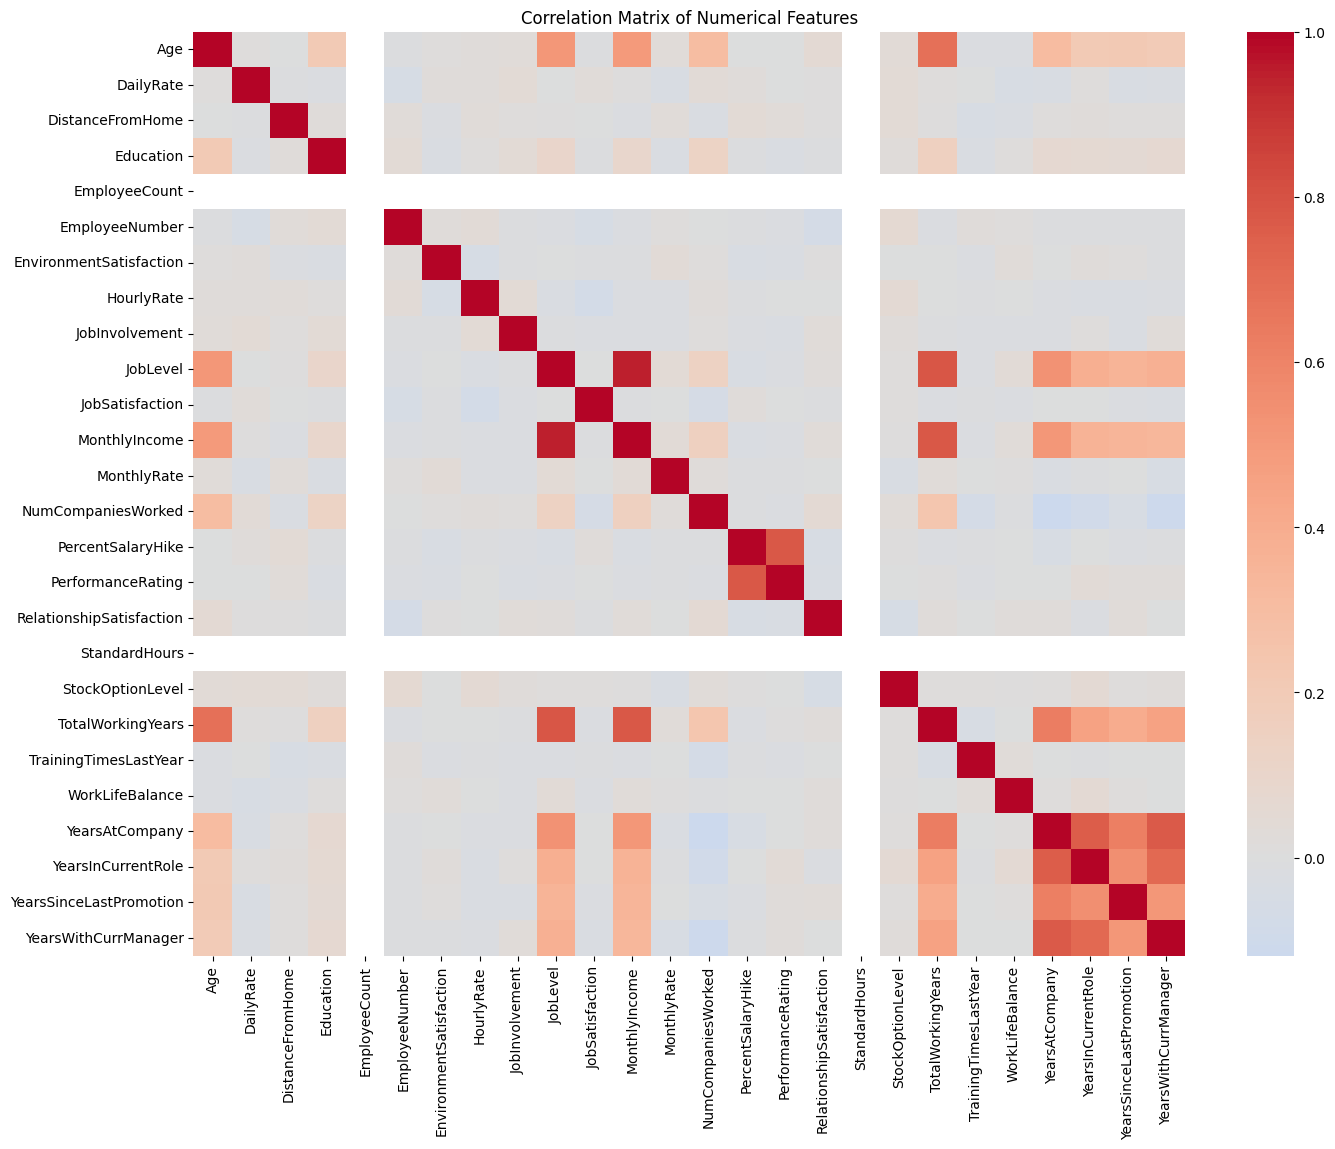

In [21]:
numeric_cols = df.select_dtypes(include="number").columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [22]:
corr_pairs = (
    corr.where(
        ~__import__("numpy").tril(
            __import__("numpy").ones(corr.shape, dtype=bool)
        )
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(15)

JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
PercentSalaryHike        PerformanceRating          0.773550
MonthlyIncome            TotalWorkingYears          0.772893
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsWithCurrManager       0.714365
Age                      TotalWorkingYears          0.680381
TotalWorkingYears        YearsAtCompany             0.628133
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
JobLevel                 YearsAtCompany             0.534739
MonthlyIncome            YearsAtCompany             0.514285
YearsSinceLastPromotion  YearsWithCurrManager       0.510224
Age                      JobLevel                   0.509604
dtype: float64

## Correlation Findings

Several groups of numerical features show strong correlation:

### Compensation and experience
- JobLevel and MonthlyIncome: r = 0.95
- JobLevel and TotalWorkingYears: r = 0.78
- MonthlyIncome and TotalWorkingYears: r = 0.77

These features contain overlapping information related to seniority, experience, and compensation.

### Tenure-related features
- YearsAtCompany and YearsWithCurrManager: r = 0.77
- YearsAtCompany and YearsInCurrentRole: r = 0.76
- YearsInCurrentRole and YearsWithCurrManager: r = 0.71

These variables measure related aspects of employee tenure.

### Other relationship
- Age and TotalWorkingYears: r = 0.68
- PercentSalaryHike and PerformanceRating: r = 0.77

### Modeling implication

Strong correlation does not automatically mean that a feature should be removed.

The effect of correlated features depends on the model being used. 
For example, correlated predictors can affect coefficient interpretation in 
linear models, while tree-based models generally handle correlated features 
more naturally.

Therefore, these features will be retained for now and evaluated during 
baseline modeling and model analysis.

In [24]:
df["AttritionBinary"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

target_corr = (
    df[numeric_cols.tolist() + ["AttritionBinary"]]
    .corr()["AttritionBinary"]
    .drop("AttritionBinary")
    .sort_values()
)

target_corr

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
EmployeeCount                    NaN
StandardHours                    NaN
Name: AttritionBinary, dtype: float64

## EDA Summary

### Main observations

1. The target is imbalanced:
   - No: ~83.9%
   - Yes: ~16.1%

2. Employees who leave tend to be:
   - younger
   - lower income
   - less experienced
   - shorter-tenured

3. OverTime has one of the strongest observed categorical associations:
   - No overtime: ~10.4% attrition
   - Overtime: ~30.5% attrition

4. Low JobSatisfaction is associated with higher attrition.

5. JobLevel shows different attrition rates across levels, but the
   relationship is not perfectly monotonic.

6. Several numerical features are strongly correlated:
   - JobLevel ↔ MonthlyIncome
   - JobLevel ↔ TotalWorkingYears
   - YearsAtCompany ↔ YearsInCurrentRole
   - YearsAtCompany ↔ YearsWithCurrManager

7. Numerical features have relatively weak individual linear correlations
   with Attrition. This does not mean they are useless because relationships
   may be nonlinear or involve interactions.

8. Extreme numerical observations were not removed solely because they were
   statistical outliers.

### Modeling implications

- The target imbalance must be considered during evaluation.
- Identifier and constant columns should be excluded from modeling.
- Categorical variables require appropriate encoding.
- Preprocessing must be fitted only on training data to avoid leakage.
- Feature selection will not be based solely on univariate correlation
- .